In [2]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *
from scipy.stats import unitary_group
from scipy.linalg import sqrtm, inv, eigh, expm, expm_frechet
from functools import reduce
import glob
from joblib import Parallel, delayed

In [16]:
def H(phi=0, beta=1, omega=1, J=1, w = []):
    H_arr = omega*(np.cos(phi)*J_x+np.sin(phi)*J_y)+ beta/(2*J) * J_z2 + w[0]*J_x + w[1]*J_y + w[2]*J_z
    return H_arr

rng = np.random.default_rng()
J = 50
dim = int(2*J+1)
t_steps = 6000
delta_t = 0.001
beta = 10
omega = 1
w = [0, 0, 0]
J_x = spin_Jx(J).full()
J_y = spin_Jy(J).full()
J_z = spin_Jz(J).full()
J_z2 = J_z @ J_z
J_x2 = J_x @ J_x

In [17]:
def single_run(phi_array):
    U = np.eye(dim, dtype=complex)
    for angle in phi_array:
        H_angle = H(phi=angle, beta=beta, omega=omega, J=J, w=w)
        U = expm(-1j * delta_t * H_angle) @ U
    return U
def single_run_trotter(phi_array):
    U = np.eye(dim, dtype=complex)
    for angle in phi_array:
        U = expm(-1j * delta_t * beta / (2*J) * J_z2) @ expm(-1j * delta_t * omega * (np.cos(angle)*J_x + np.sin(angle)*J_y)) @ U
    return U

def level_spacings_unitary(eigvals):
    angles = np.angle(eigvals)
    angles = np.sort(angles)
    spacings = np.diff(angles)
    spacings = np.append(spacings, 2*np.pi - (angles[-1] - angles[0]))
    # Unfold spectrum: divide by mean spacing
    spacings /= np.mean(spacings)
    return spacings
def fixed_phases(t_steps):
    seq = np.array([0, 1, 2, 3])
    return np.pi/2 * np.resize(seq, t_steps)
s = np.linspace(0, 4, 200)
P_Wigner_2 = 32/(np.pi**2) * s**2 *np.exp(-4 * s**2/np.pi)
P_Wigner_1 = (np.pi/2) * s * np.exp(-np.pi * s**2 /4)
P_Poisson = np.exp(-s)

Control Unitary level spacings

In [18]:
iter = 1
# Parallel execution
t_steps_array = np.array([6000, 40000])
beta_array = np.array([10])
spacings = np.empty((t_steps_array.shape[0],beta_array.shape[0]), dtype = object)
for t, t_steps in enumerate(t_steps_array):
        for b, beta in enumerate(beta_array):
                phi_array = [delta_t * np.arange(t_steps) for _ in range(iter)]
                U_total = np.array(Parallel(n_jobs=4)(delayed(single_run)(phi) for phi in phi_array))
                spacings_U_total = np.concatenate([level_spacings_unitary(np.linalg.eigvals(U)) for U in U_total])
                spacings[t,b] = spacings_U_total
                del U_total
                del spacings_U_total
                print(f"Completed t_steps = {t_steps}, beta = {beta}")

Completed t_steps = 6000, beta = 10
Completed t_steps = 40000, beta = 10


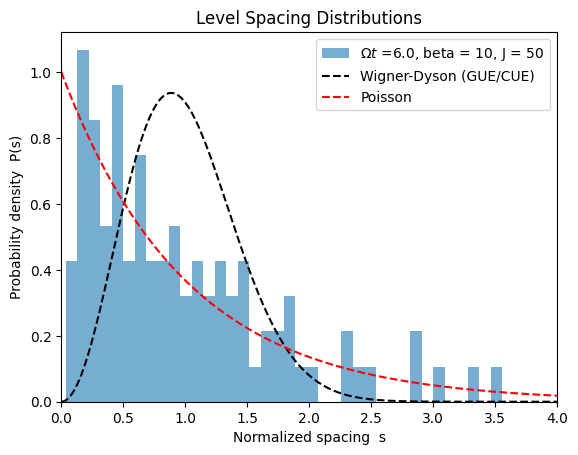

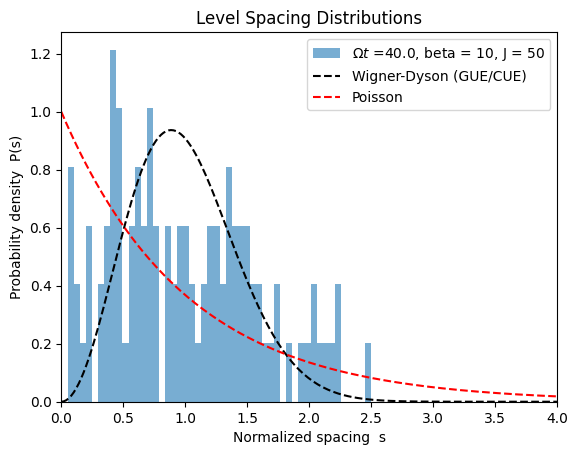

In [19]:
for t, t_steps in enumerate(t_steps_array):
        for b, beta in enumerate(beta_array):
                plt.hist(spacings[t,b], bins=50, density=True, alpha=0.6, label=f'$\Omega t$ ={t_steps*delta_t}, beta = {beta}, J = {J}')
                plt.plot(s, P_Wigner_2, 'k--', label='Wigner-Dyson (GUE/CUE)')
                plt.plot(s, P_Poisson, 'r--', label='Poisson')
                plt.xlabel('Normalized spacing  s')
                plt.ylabel('Probability density  P(s)')
                plt.title('Level Spacing Distributions')
                plt.legend()
                plt.xlim(0, 4)
                plt.show()

Random Matrix Ensembles

In [21]:
# Generate ensembles
n = 10  # matrix dimension
N = 100  # number of samples

# Chaotic system: GUE random matrices (hermitian)
def GUE_matrix(n):
    A = np.random.randn(n, n) + 1j * np.random.randn(n, n)
    return (A + A.conj().transpose()) / 2  # Hermitian

def random_unitary(n):
    A = np.random.randn(n, n) + 1j * np.random.randn(n, n)
    return expm(1j * (A + A.conj().transpose())/(2 * np.sqrt(n)))  # Unitary

# Integrable system: random diagonal (uncorrelated levels)
def random_diagonal(n):
    return np.diag(np.random.randn(n))

def level_spacings_hermitian(H):
    eigvals = np.linalg.eigvalsh(H)
    eigvals = np.sort(eigvals)
    spacings = np.diff(eigvals)
    # Unfold spectrum: divide by mean spacing
    spacings /= np.mean(spacings)
    return spacings

# Gather data
spacings_unitary = np.concatenate([level_spacings_unitary(np.linalg.eigvals(random_unitary(n))) for _ in range(N)])
spacings_GUE = np.concatenate([level_spacings_hermitian(GUE_matrix(n)) for _ in range(N)])
spacings_CUE = np.concatenate([level_spacings_unitary(np.linalg.eigvals(unitary_group.rvs(n))) for _ in range(N)])
spacings_Poisson = np.concatenate([level_spacings_hermitian(random_diagonal(n)) for _ in range(N)])
#spacings_U_total = np.concatenate([level_spacings_unitary(U) for U in U_total])


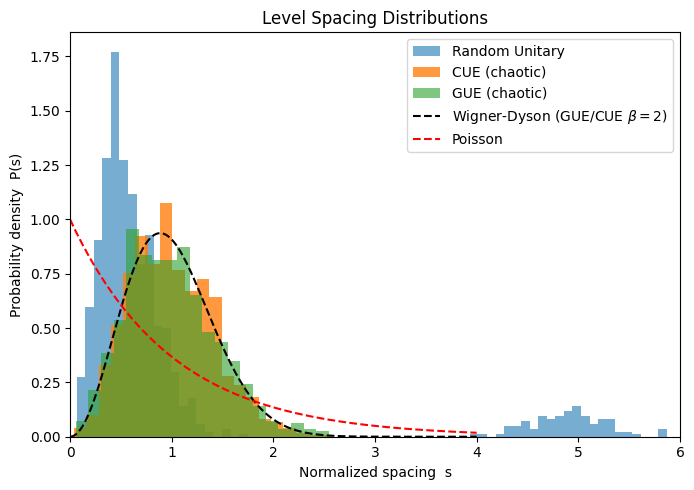

In [73]:

# Plot histograms
plt.figure(figsize=(7,5))
plt.hist(spacings_unitary, bins='auto', density=True, alpha=0.6, label='Random Unitary')
plt.hist(spacings_CUE, bins='auto', density=True, alpha=0.8, label='CUE (chaotic)')
plt.hist(spacings_GUE, bins='auto', density=True, alpha=0.6, label='GUE (chaotic)')
#plt.hist(spacings_Poisson, bins=80, density=True, alpha=0.6, label='Poisson (integrable)')

# Overlay theoretical curves
plt.plot(s, P_Wigner_2, 'k--', label='Wigner-Dyson (GUE/CUE $\\beta = 2$)')
plt.plot(s, P_Poisson, 'r--', label='Poisson')

plt.xlabel('Normalized spacing  s')
plt.ylabel('Probability density  P(s)')
plt.title('Level Spacing Distributions')
plt.legend()
plt.tight_layout()
plt.xlim(0,6)
plt.show()



Kicked Top

In [ ]:
def kicked_top_unitary(kappa_z, kappa_x, p, n_kicks):
    U_kick = expm(-1j * kappa_x / (2*J) * J_x2) @ expm(-1j * kappa_z / (2*J) * J_z2) @ expm(-1j * p * J_z)
    return np.linalg.matrix_power(U_kick, n_kicks)


R_x = expm(-1j * np.pi * J_x)
R_y = expm(-1j * np.pi * J_y)
R_z = expm(-1j * np.pi * J_z)
def KT_parity(unitary, operator, parity, tol=1e-8):
    """
    Separate a matrix of eigenvectors into two groups based on whether they
    are eigenvectors of `operator` with eigenvalue +1 or -1.

    Parameters
    ----------
    eigvecs : np.ndarray
        Matrix whose columns are eigenvectors (shape: N x M)
    operator : np.ndarray
        Hermitian or unitary operator acting on the same space (shape: N x N)
    tol : float
        Numerical tolerance for distinguishing eigenvalues (default 1e-8)

    Returns
    -------
    eigvecs_plus : np.ndarray
        Submatrix of eigvecs corresponding to eigenvalue +1 under operator.
    eigvecs_minus : np.ndarray
        Submatrix of eigvecs corresponding to eigenvalue -1 under operator.
    """
    eigvecs_plus = []
    eigvecs_minus = []
    eigvecs = np.linalg.eig(unitary)[1]
    for i in range(eigvecs.shape[1]):
        v = eigvecs[:, i]
        # Compute the action of the operator on v
        Ov = operator @ v
        # Estimate eigenvalue: <v|O|v> / <v|v>
        lam = np.vdot(v, Ov) / np.vdot(v, v)

        if np.isclose(lam, 1.0, atol=tol):
            eigvecs_plus.append(v)
        elif np.isclose(lam, -1.0, atol=tol):
            eigvecs_minus.append(v)
        else:
            raise ValueError(f"Eigenvector {i} does not have eigenvalue close to +1 or -1 (estimated eigenvalue: {lam})")
    # Stack vectors back into matrices
    eigvecs_plus = np.column_stack(eigvecs_plus)
    eigvecs_minus = np.column_stack(eigvecs_minus)
    if parity == 'even' or parity == 1:
        return eigvecs_plus.conjugate().transpose() @ unitary @ eigvecs_plus
    elif parity == 'odd' or parity == -1:
        return eigvecs_minus.conjugate().transpose() @ unitary @ eigvecs_minus


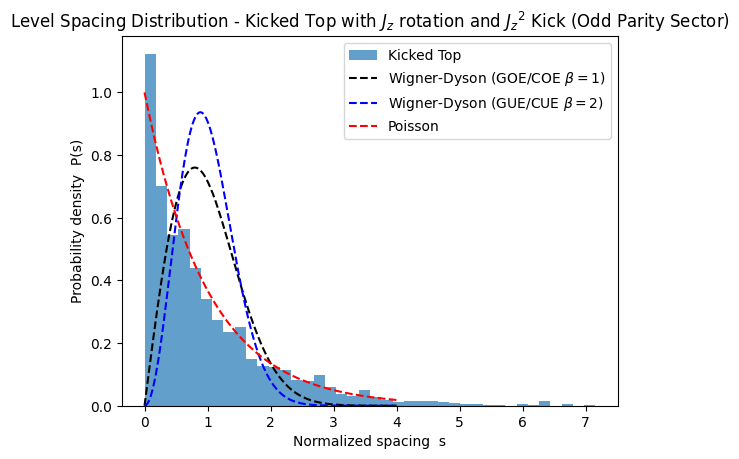

In [ ]:
kappa = 10.5
n_kicks = 1
p = 1.7
KT_spacings = np.concatenate([level_spacings_unitary(np.linalg.eigvals(KT_parity(kicked_top_unitary(k, 0, p, n_kicks), R_x, -1))) for k in np.linspace(10, 10.5, num=10)])
#KT_spacings = np.concatenate([level_spacings_unitary(np.linalg.eigvals(kicked_top_unitary(k, 0, p, n_kicks))) for k in np.linspace(10, 10.5, num=10)])
plt.hist(KT_spacings, bins='auto', density=True, alpha=0.7, label='Kicked Top')
plt.plot(s, P_Wigner_1, 'k--', label='Wigner-Dyson (GOE/COE $\\beta = 1$)')
plt.plot(s, P_Wigner_2, 'b--', label='Wigner-Dyson (GUE/CUE $\\beta = 2$)')
plt.plot(s, P_Poisson, 'r--', label='Poisson')
plt.xlabel('Normalized spacing  s')
plt.ylabel('Probability density  P(s)')
plt.title('Level Spacing Distribution - Kicked Top with ${J_x}$ rotation and ${J_z}^2$ Kick (Odd Parity Sector)')
plt.legend()
plt.show()